<a href="https://colab.research.google.com/github/Dana-Mutairi/advanced-pixel-manipulation/blob/main/Assignment_1_Advanced_Pixel_Manipulation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 1: Advanced Pixel-Level Manipulation

## Objective

This project demonstrates advanced pixel-level image manipulation using NumPy, PIL, and OpenCV in Google Colab.

The project includes:

- Loading, inspecting, and displaying two images.
- Direct manipulation of image matrices using NumPy.
- Cropping a 30 × 30 pixel region from a random location in Image 1.
- Pasting the cropped region into Image 2 to create Image 3.
- Converting Image 1, Image 2, and Image 3 to grayscale.
- Applying a custom sharpening kernel to Image 3.

## 1. Import Required Libraries

The project uses NumPy for array manipulation, PIL for loading images,
OpenCV for color conversion and filtering, and Matplotlib for displaying
the results.

In [128]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image

In [129]:
!wget -q "https://raw.githubusercontent.com/Dana-Mutairi/advanced-pixel-manipulation/main/assignment1image.jpg" -O assignment1image.jpg
!wget -q "https://raw.githubusercontent.com/Dana-Mutairi/advanced-pixel-manipulation/main/assignment1image2.jpg" -O assignment1image2.jpg

print("Images downloaded successfully.")

Images downloaded successfully.


## 2. Loading, Inspecting, and Displaying the Images

Two images are loaded using PIL and converted to RGB format to ensure a
consistent three-channel color representation. Their dimensions, color
modes, NumPy shapes, data types, and pixel-value ranges are inspected
before performing any image manipulation.


In [130]:
image1_pil = Image.open("assignment1image.jpg").convert("RGB")
image2_pil = Image.open("assignment1image2.jpg").convert("RGB")

In [131]:
image1 = np.array(image1_pil)
image2 = np.array(image2_pil)

print("assignment1image.jpg")
print("Size (width, height):", image1_pil.size)
print("Color mode:", image1_pil.mode)
print("Array shape:", image1.shape)
print("Data type:", image1.dtype)
print("Pixel-value range:", image1.min(), "to", image1.max())

print("\nassignment1image2.jpg")
print("Size (width, height):", image2_pil.size)
print("Color mode:", image2_pil.mode)
print("Array shape:", image2.shape)
print("Data type:", image2.dtype)
print("Pixel-value range:", image2.min(), "to", image2.max())

assignment1image.jpg
Size (width, height): (199, 148)
Color mode: RGB
Array shape: (148, 199, 3)
Data type: uint8
Pixel-value range: 0 to 255

assignment1image2.jpg
Size (width, height): (194, 182)
Color mode: RGB
Array shape: (182, 194, 3)
Data type: uint8
Pixel-value range: 0 to 255


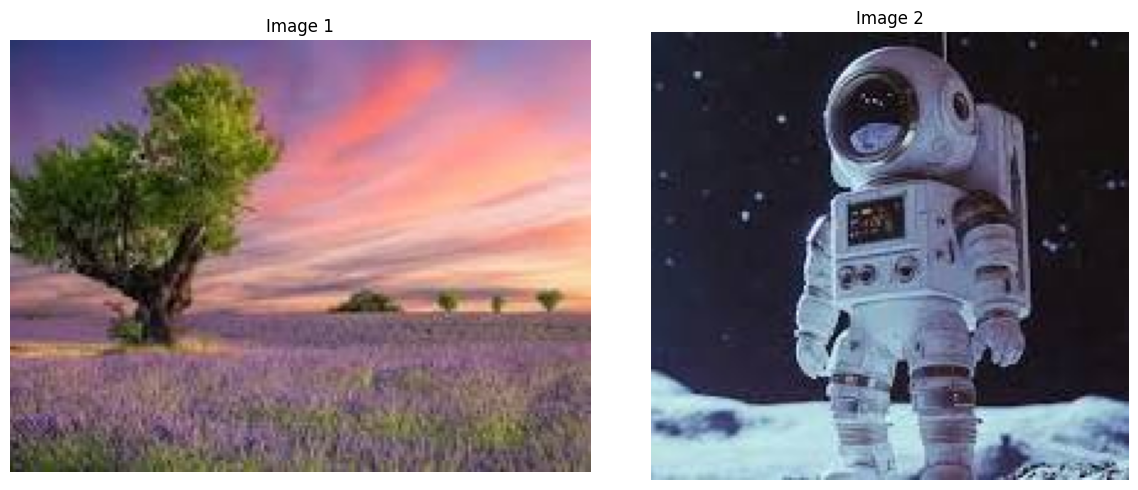

In [132]:
plt.figure(figsize=(12, 5))

# Display Image 1
plt.subplot(1, 2, 1)
plt.imshow(image1)
plt.title("Image 1")
plt.axis("off")

# Display Image 2
plt.subplot(1, 2, 2)
plt.imshow(image2)
plt.title("Image 2")
plt.axis("off")

plt.tight_layout()
plt.show()

## 3. Random 30 × 30 Pixel Crop

A valid random location is generated using NumPy. A 30 × 30 pixel region is then extracted from Image 1 using array slicing.


Crop starting coordinate (x, y): (35, 116)
Cropped region shape: (30, 30, 3)


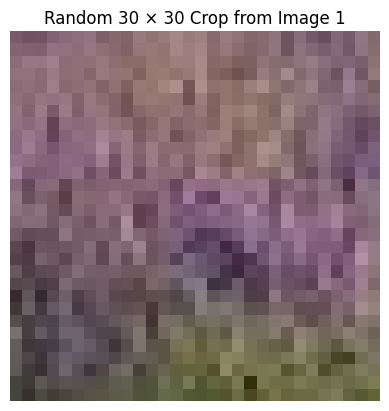

In [133]:
crop_size = 30

# Get Image 1 dimensions
height1, width1 = image1.shape[:2]

# Generate a random valid starting location
crop_y = np.random.randint(0, height1 - crop_size + 1)
crop_x = np.random.randint(0, width1 - crop_size + 1)

# Crop a 30 × 30 region from Image 1
cropped_region = image1[
    crop_y:crop_y + crop_size,
    crop_x:crop_x + crop_size
]

print("Crop starting coordinate (x, y):", (crop_x, crop_y))
print("Cropped region shape:", cropped_region.shape)

# Display the cropped region
plt.imshow(cropped_region)
plt.title("Random 30 × 30 Crop from Image 1")
plt.axis("off")
plt.show()

## 4. Creating Image 3

A copy of Image 2 is created to preserve the original image. A random valid location is generated, and the 30 × 30 region from Image 1 is pasted into the copy using NumPy array slicing. The result is named Image 3.


Paste starting coordinate (x, y): (41, 94)
Image 3 shape: (182, 194, 3)


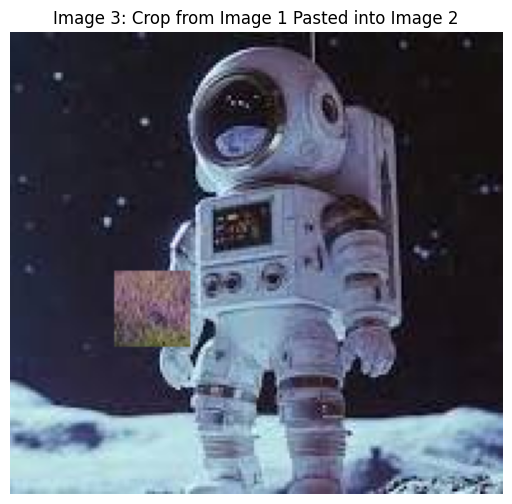

In [134]:
# Create Image 3 as a separate copy of Image 2
image3 = image2.copy()

# Get the height and width of Image 3
height2, width2 = image3.shape[:2]

# Generate a valid random location for pasting
paste_y = np.random.randint(0, height2 - crop_size + 1)
paste_x = np.random.randint(0, width2 - crop_size + 1)

# Paste the cropped region into Image 3
image3[
    paste_y:paste_y + crop_size,
    paste_x:paste_x + crop_size
] = cropped_region

print("Paste starting coordinate (x, y):", (paste_x, paste_y))
print("Image 3 shape:", image3.shape)

# Display Image 3
plt.figure(figsize=(7, 6))
plt.imshow(image3)
plt.title("Image 3: Crop from Image 1 Pasted into Image 2")
plt.axis("off")
plt.show()

## 5. Grayscale Conversion

Image 1, Image 2, and Image 3 are converted from the RGB color space to grayscale using OpenCV. A grayscale image contains one intensity channel instead of three RGB color channels.

In [135]:
# Convert all three images from RGB to grayscale
gray_image1 = cv2.cvtColor(image1, cv2.COLOR_RGB2GRAY)
gray_image2 = cv2.cvtColor(image2, cv2.COLOR_RGB2GRAY)
gray_image3 = cv2.cvtColor(image3, cv2.COLOR_RGB2GRAY)

# Inspect the grayscale image shapes
print("Grayscale Image 1 shape:", gray_image1.shape)
print("Grayscale Image 2 shape:", gray_image2.shape)
print("Grayscale Image 3 shape:", gray_image3.shape)

Grayscale Image 1 shape: (148, 199)
Grayscale Image 2 shape: (182, 194)
Grayscale Image 3 shape: (182, 194)


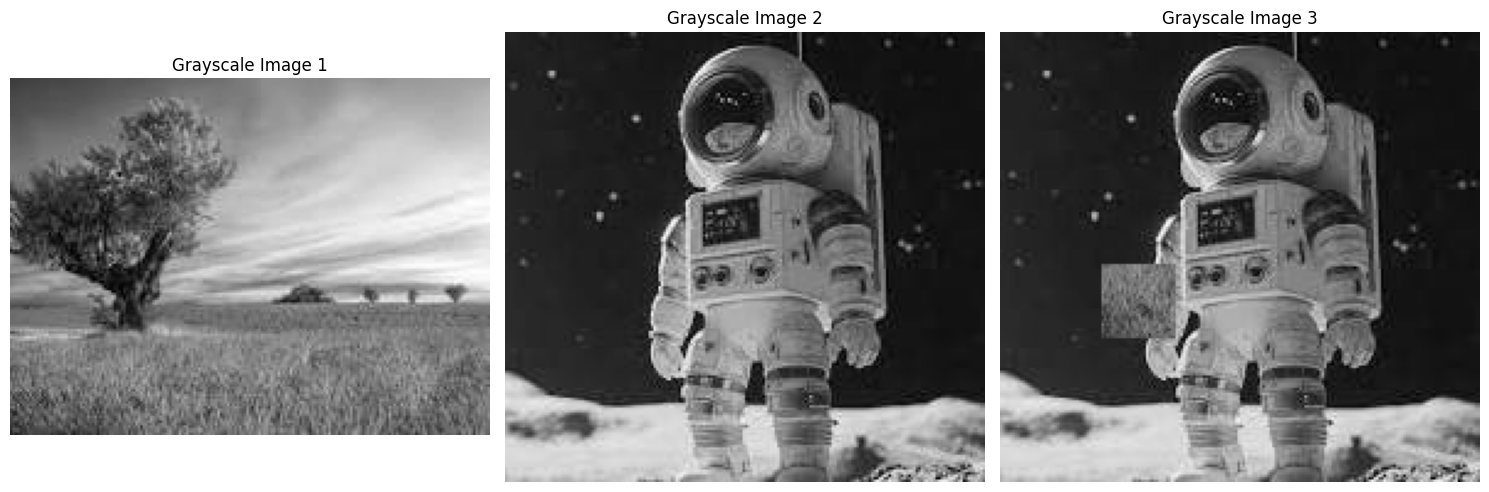

In [136]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(gray_image1, cmap="gray")
plt.title("Grayscale Image 1")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(gray_image2, cmap="gray")
plt.title("Grayscale Image 2")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(gray_image3, cmap="gray")
plt.title("Grayscale Image 3")
plt.axis("off")

plt.tight_layout()
plt.show()

## 6. Sharpening Image 3

A custom 3 × 3 sharpening kernel is applied to the grayscale version of Image 3. The kernel emphasizes differences between neighboring pixels, making edges appear clearer and sharper.

In [137]:
# Define a custom 3 × 3 sharpening kernel
sharpening_kernel = np.array([
    [ 0, -1,  0],
    [-1,  5, -1],
    [ 0, -1,  0]
])

print("Sharpening kernel:")
print(sharpening_kernel)

# Apply the kernel to grayscale Image 3
sharpened_image3 = cv2.filter2D(
    gray_image3,
    ddepth=-1,
    kernel=sharpening_kernel
)

Sharpening kernel:
[[ 0 -1  0]
 [-1  5 -1]
 [ 0 -1  0]]


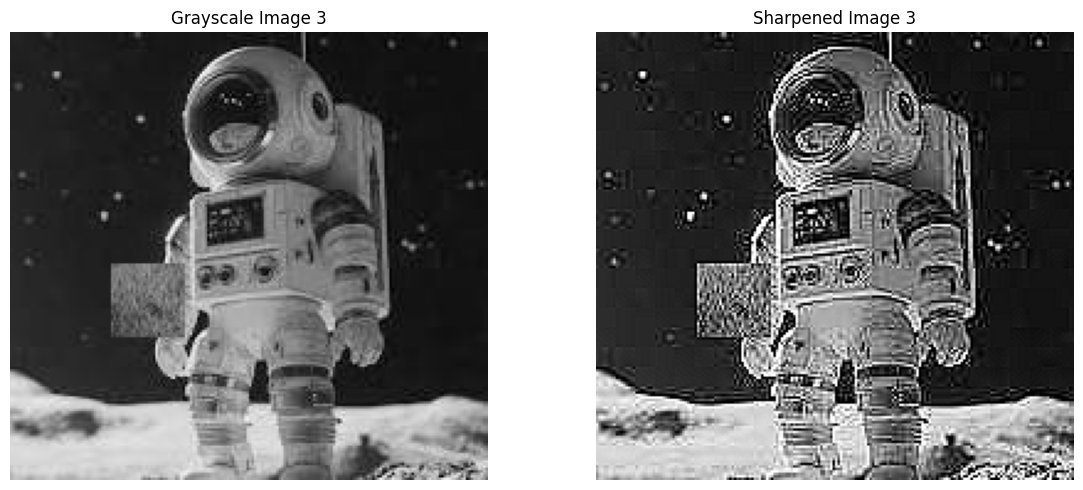

In [138]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(gray_image3, cmap="gray")
plt.title("Grayscale Image 3")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(sharpened_image3, cmap="gray")
plt.title("Sharpened Image 3")
plt.axis("off")

plt.tight_layout()
plt.show()

## 7. Saving the Results

The generated Image 3, grayscale images, and sharpened Image 3 are saved as PNG files so they can be reused or included in the project repository.

In [139]:
# Save all generated results
Image.fromarray(image3).save("Image3.png")
Image.fromarray(gray_image1).save("Grayscale_Image1.png")
Image.fromarray(gray_image2).save("Grayscale_Image2.png")
Image.fromarray(gray_image3).save("Grayscale_Image3.png")
Image.fromarray(sharpened_image3).save("Sharpened_Image3.png")

print("All result images were saved successfully.")

All result images were saved successfully.


## 8. Conclusion

This project demonstrated direct pixel-level image manipulation using NumPy, PIL, and OpenCV. Two images were loaded, inspected, and converted into NumPy arrays. A random 30 × 30 pixel region was cropped from Image 1 and pasted at a random valid location in Image 2 to create Image 3. All three images were converted from RGB to grayscale. Finally, a custom 3 × 3 sharpening kernel was applied to grayscale Image 3 to enhance its edges.

The project demonstrates array slicing, random coordinate generation, color-space transformation, image copying, and custom kernel filtering.